<a href="https://colab.research.google.com/github/LiNlIn4968/LiNlIn4968/blob/main/VCO_based_AFE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

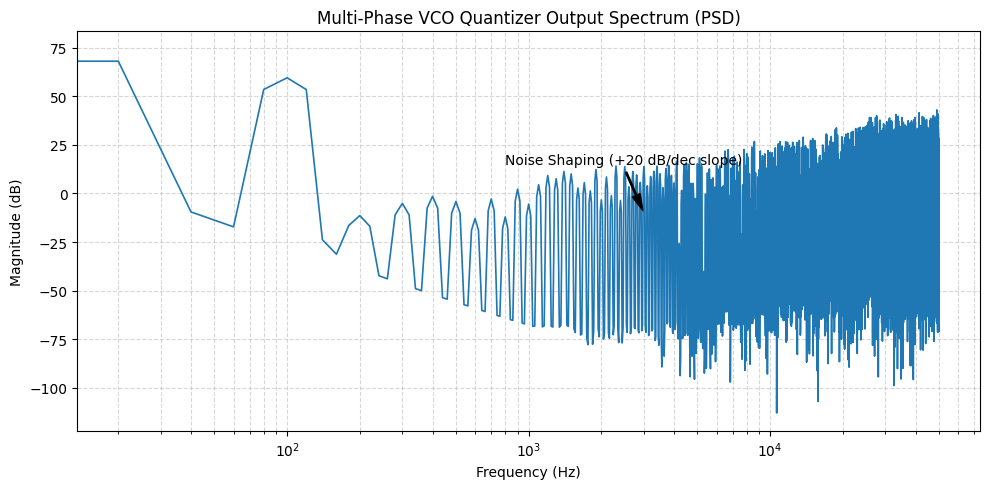

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 仿真参数与信号设置
# ==========================================
fs = 100e3          # 采样频率 System Sampling Rate: 100 kHz
dt = 1e-8           # 连续时间模拟精度: 10 ns
t_total = 0.05      # 仿真时间: 50 ms
t_cont = np.arange(0, t_total, dt)

# 输入微弱神经信号 (例如 100 Hz 正弦波)
f_sig = 100
A_sig = 0.5         # 归一化幅度
v_in = A_sig * np.sin(2 * np.pi * f_sig * t_cont)

# VCO 参数
f0 = 20e3           # VCO 中心频率 Base frequency: 20 kHz
Kvco = 15e3         # VCO 调谐灵敏度 Gain: 15 kHz/V
N_stages = 5        # 5 级环形振荡器 (5 个多相节点)

# ==========================================
# 2. 连续时间 VCO 相位演化 (Phase Accumulation)
# ==========================================
# 瞬间频率 f(t) = f0 + Kvco * v_in(t)
inst_freq = f0 + Kvco * v_in
# 连续时间相位积分 (以半周期/翻转事件为单位化)
# 1 个完整的 VCO 周期内，5 级反相器共有 2*N_stages = 10 次翻转事件
phi_cont = 2 * N_stages * np.cumsum(inst_freq) * dt

# ==========================================
# 3. 采样与多相节点状态量化 (Multi-Phase Quantization)
# ==========================================
sample_steps = int(1 / (fs * dt))
sample_indices = np.arange(0, len(t_cont), sample_steps)

# 离散时间采样点上的连续相位
phi_sampled_ideal = phi_cont[sample_indices]

# 多相节点量化：直接向下取整代表当前翻转事件的累计 index
# 相当于在采样时刻用 DFF 读取 5 个节点输出的组合逻辑状态
phi_quantized = np.floor(phi_sampled_ideal)

# ==========================================
# 4. 相位差分 (Phase Difference -> 离散输出)
# ==========================================
# 连续两次采样的相位增量 \Delta\Phi[k] = \Phi[k] - \Phi[k-1]
# 天然实现 (1 - z^-1) 的高通差分，形成一阶噪声整形
out_digital = np.diff(phi_quantized, prepend=phi_quantized[0])

# ==========================================
# 5. 频谱分析 (PSD) 验证噪声整形
# ==========================================
N_fft = len(out_digital)
freqs = np.fft.rfftfreq(N_fft, d=1/fs)
fft_out = np.abs(np.fft.rfft(out_digital * np.hanning(N_fft)))

plt.figure(figsize=(10, 5))
plt.plot(freqs, 20 * np.log10(fft_out + 1e-12), color='#1f77b4', linewidth=1.2)
plt.xscale('log')
plt.title('Multi-Phase VCO Quantizer Output Spectrum (PSD)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, which="both", ls="--", alpha=0.5)

# 标注 1/f 高通噪声整形斜率 (20 dB/dec)
plt.annotate('Noise Shaping (+20 dB/dec slope)', xy=(3e3, -10), xytext=(8e2, 15),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))
plt.tight_layout()
plt.show()

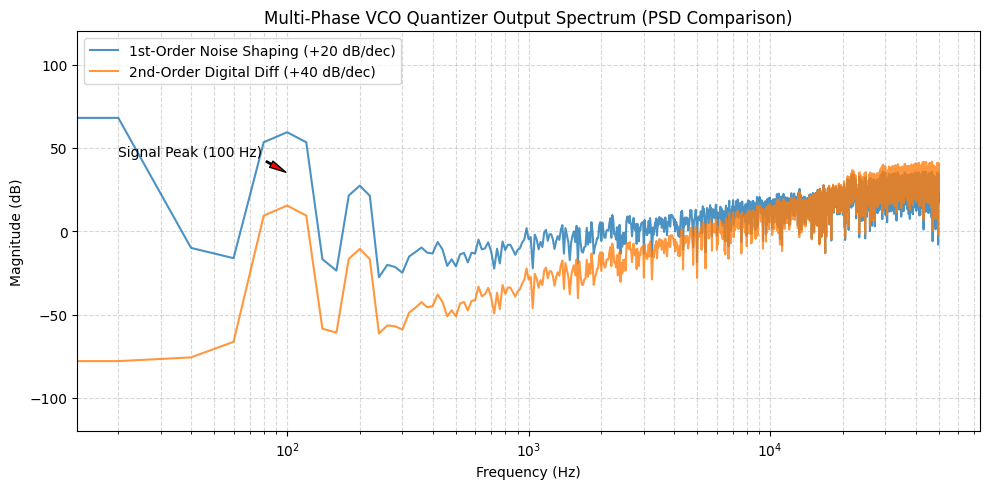

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 仿真参数与信号设置
# ==========================================
fs = 100e3          # 采样频率 System Sampling Rate: 100 kHz
dt = 1e-8           # 连续时间模拟精度: 10 ns
t_total = 0.05      # 仿真时间: 50 ms
t_cont = np.arange(0, t_total, dt)

# 输入微弱神经信号 (100 Hz 正弦波)
f_sig = 100
A_sig = 0.5         # 归一化幅度
v_in = A_sig * np.sin(2 * np.pi * f_sig * t_cont)

# VCO 参数 (含二次非线性)
f0 = 20e3           # VCO 中心频率: 20 kHz
Kvco1 = 15e3        # 一阶灵敏度: 15 kHz/V
Kvco2 = 1.5e3       # 二阶非线性系数 (引入 HD2 失真): 1.5 kHz/V^2
N_stages = 5        # 5 级环形振荡器 (5 个多相节点)

# ==========================================
# 2. 连续时间 VCO 相位演化 (含非线性)
# ==========================================
# 瞬间频率 f(t) = f0 + Kvco1 * v_in(t) + Kvco2 * v_in(t)^2
inst_freq = f0 + Kvco1 * v_in + Kvco2 * (v_in ** 2)

# 连续时间相位积分 (以半周期/翻转事件为单位化)
phi_cont = 2 * N_stages * np.cumsum(inst_freq) * dt

# ==========================================
# 3. 采样与多相节点状态量化 (Multi-Phase Quantization)
# ==========================================
sample_steps = int(1 / (fs * dt))
sample_indices = np.arange(0, len(t_cont), sample_steps)

# 离散时间采样点上的连续相位与下取整量化
phi_sampled_ideal = phi_cont[sample_indices]
phi_quantized = np.floor(phi_sampled_ideal)

# ==========================================
# 4. 相位差分 (一阶与二阶噪声整形)
# ==========================================
# 1st-order Difference: (1 - z^-1)
out_1st = np.diff(phi_quantized, prepend=phi_quantized[0])

# 2nd-order Difference: (1 - z^-1)^2
out_2nd = np.diff(out_1st, prepend=out_1st[0])

# ==========================================
# 5. 频谱分析 (PSD) 绘图对比
# ==========================================
N_fft = len(out_1st)
freqs = np.fft.rfftfreq(N_fft, d=1/fs)

win = np.hanning(N_fft)
fft_1st = np.abs(np.fft.rfft(out_1st * win))
fft_2nd = np.abs(np.fft.rfft(out_2nd * win))

plt.figure(figsize=(10, 5))
plt.plot(freqs, 20 * np.log10(fft_1st + 1e-12), label='1st-Order Noise Shaping (+20 dB/dec)', color='#1f77b4', alpha=0.8)
plt.plot(freqs, 20 * np.log10(fft_2nd + 1e-12), label='2nd-Order Digital Diff (+40 dB/dec)', color='#ff7f0e', alpha=0.8)

plt.xscale('log')
plt.title('Multi-Phase VCO Quantizer Output Spectrum (PSD Comparison)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.ylim(-120, 120)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='upper left')

# 标注输入信号峰值与谐波失真 (HD2)
plt.annotate(f'Signal Peak ({f_sig} Hz)', xy=(f_sig, 35), xytext=(20, 45),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=5))

plt.tight_layout()
plt.show()

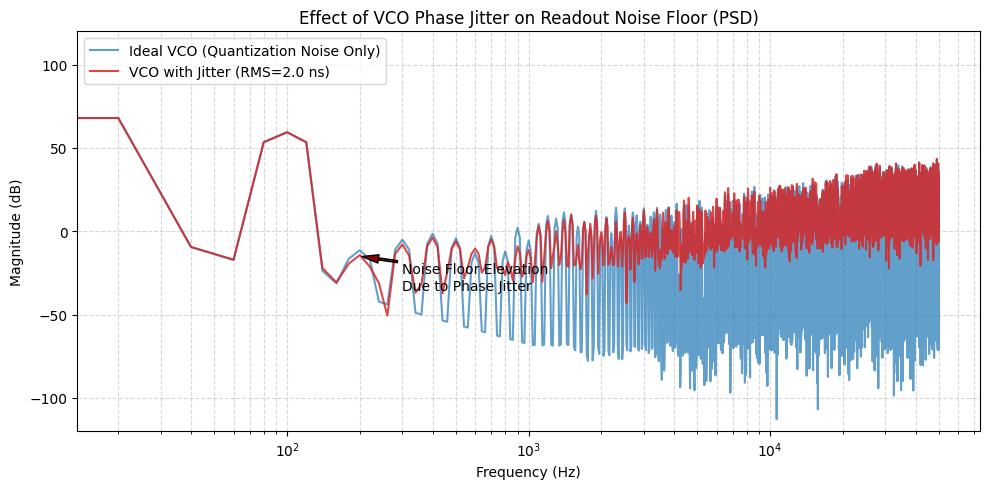

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 仿真参数与信号设置
# ==========================================
fs = 100e3          # 采样频率 System Sampling Rate: 100 kHz
dt = 1e-8           # 连续时间模拟精度: 10 ns
t_total = 0.05      # 仿真时间: 50 ms
t_cont = np.arange(0, t_total, dt)

# 输入微弱神经信号 (100 Hz 正弦波)
f_sig = 100
A_sig = 0.5         # 归一化幅度
v_in = A_sig * np.sin(2 * np.pi * f_sig * t_cont)

# VCO 参数
f0 = 20e3           # VCO 中心频率: 20 kHz
Kvco1 = 15e3        # 一阶灵敏度: 15 kHz/V
N_stages = 5        # 5 级环形振荡器 (5 个多相节点)

# ==========================================
# 2. 相位抖动 (Phase Jitter / Phase Noise) 设置
# ==========================================
# 假设单个振荡周期 T0 = 1/f0 的边缘标准差 (RMS Jitter)
# 典型 65nm CMOS 低功耗 Ring-VCO 的 Jitter 约在几 ns 到十几 ns 数量级
sigma_jitter = 2e-9  # 2 ns RMS Period Jitter

# 计算连续时间微小步长 dt 对应注入的累积相位标准差
# 相位随机游走的标准差满足: \sigma_phase(dt) = 2 \pi * f0 * \sigma_jitter * sqrt(dt / T0)
T0 = 1 / f0
sigma_phi_dt = 2 * np.pi * f0 * sigma_jitter * np.sqrt(dt / T0)

# 生成独立的连步长高斯随机相位噪声增量 (White Frequency Noise -> Random Walk Phase)
np.random.seed(42)  # 固定随机数种子保证可复现
phase_noise_dt = np.random.normal(loc=0.0, scale=sigma_phi_dt, size=len(t_cont))

# ==========================================
# 3. 连续时间 VCO 相位演化 (信号 + 抖动)
# ==========================================
inst_freq = f0 + Kvco1 * v_in

# 理想信号累积相位 (单位化为 2*N_stages 个半周期翻转事件)
phi_ideal_cont = 2 * N_stages * np.cumsum(inst_freq) * dt

# 叠加由热噪声引起的累积相位抖动 ( Wiener Process Phase Noise )
# 归一化因子: 1 个周期 2*pi 对应 2*N_stages 个相位步长
phi_noise_cont = (2 * N_stages / (2 * np.pi)) * np.cumsum(phase_noise_dt)

# 最终带相位抖动的总连续相位
phi_total_cont = phi_ideal_cont + phi_noise_cont

# ==========================================
# 4. 采样与多相节点状态量化 (Quantization)
# ==========================================
sample_steps = int(1 / (fs * dt))
sample_indices = np.arange(0, len(t_cont), sample_steps)

# 理想与含 Jitter 状态下的采样与量化
phi_quant_ideal = np.floor(phi_ideal_cont[sample_indices])
phi_quant_jitter = np.floor(phi_total_cont[sample_indices])

# 一阶差分输出
out_ideal = np.diff(phi_quant_ideal, prepend=phi_quant_ideal[0])
out_jitter = np.diff(phi_quant_jitter, prepend=phi_quant_jitter[0])

# ==========================================
# 5. 频谱分析 (PSD) 评估 Jitter 对带内底噪的影响
# ==========================================
N_fft = len(out_ideal)
freqs = np.fft.rfftfreq(N_fft, d=1/fs)
win = np.hanning(N_fft)

fft_ideal = np.abs(np.fft.rfft(out_ideal * win))
fft_jitter = np.abs(np.fft.rfft(out_jitter * win))

plt.figure(figsize=(10, 5))
plt.plot(freqs, 20 * np.log10(fft_ideal + 1e-12), label='Ideal VCO (Quantization Noise Only)', color='#1f77b4', alpha=0.7)
plt.plot(freqs, 20 * np.log10(fft_jitter + 1e-12), label=f'VCO with Jitter (RMS={sigma_jitter*1e9:.1f} ns)', color='#d62728', alpha=0.85)

plt.xscale('log')
plt.title('Effect of VCO Phase Jitter on Readout Noise Floor (PSD)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.ylim(-120, 120)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='upper left')

# 标注低频带内底噪抬升区域
plt.annotate('Noise Floor Elevation\nDue to Phase Jitter', xy=(200, -15), xytext=(300, -35),
             arrowprops=dict(facecolor='darkred', shrink=0.05, width=1.5, headwidth=6))

plt.tight_layout()
plt.show()

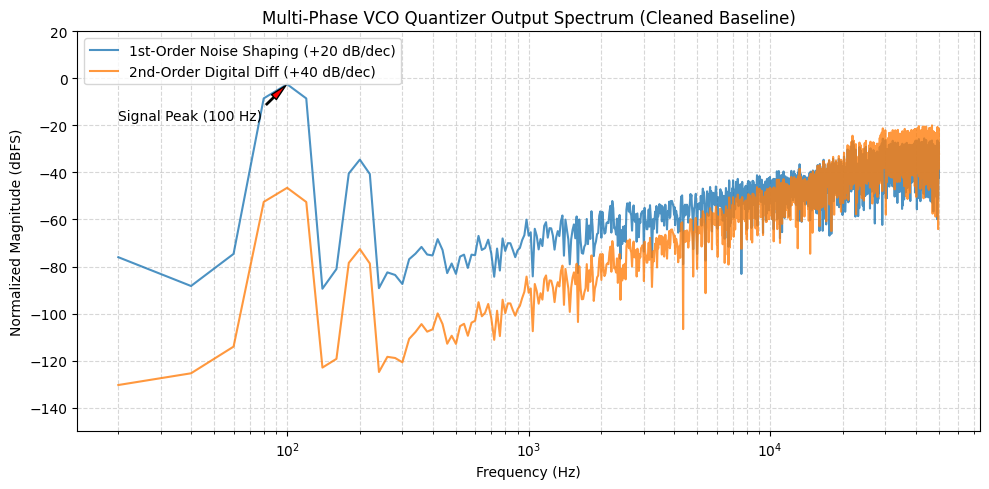

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 仿真参数与信号设置
# ==========================================
fs = 100e3          # 采样频率 System Sampling Rate: 100 kHz
dt = 1e-8           # 连续时间模拟精度: 10 ns
t_total = 0.05      # 仿真时间: 50 ms
t_cont = np.arange(0, t_total, dt)

# 输入微弱神经信号 (100 Hz 正弦波)
f_sig = 100
A_sig = 0.5         # 归一化幅度
v_in = A_sig * np.sin(2 * np.pi * f_sig * t_cont)

# VCO 参数 (含二次非线性)
f0 = 20e3           # VCO 中心频率: 20 kHz
Kvco1 = 15e3        # 一阶灵敏度: 15 kHz/V
Kvco2 = 1.5e3       # 二阶非线性系数 (引入 HD2 失真): 1.5 kHz/V^2
N_stages = 5        # 5 级环形振荡器 (5 个多相节点)

# ==========================================
# 2. 连续时间 VCO 相位演化 (含非线性)
# ==========================================
# 瞬间频率 f(t) = f0 + Kvco1 * v_in(t) + Kvco2 * v_in(t)^2
inst_freq = f0 + Kvco1 * v_in + Kvco2 * (v_in ** 2)

# 连续时间相位积分 (以半周期/翻转事件为单位化)
phi_cont = 2 * N_stages * np.cumsum(inst_freq) * dt

# ==========================================
# 3. 采样与多相节点状态量化 (Multi-Phase Quantization)
# ==========================================
sample_steps = int(1 / (fs * dt))
sample_indices = np.arange(0, len(t_cont), sample_steps)

# 离散时间采样点上的连续相位与下取整量化
phi_sampled_ideal = phi_cont[sample_indices]
phi_quantized = np.floor(phi_sampled_ideal)

# ==========================================
# 4. 相位差分 (修复点 1：不使用 prepend，改用纯向量差分)
# ==========================================
# 1st-order Difference: (1 - z^-1)
out_1st = np.diff(phi_quantized)

# 2nd-order Difference: (1 - z^-1)^2
out_2nd = np.diff(out_1st)

# ==========================================
# 5. 信号预处理 (修复点 2：去除 DC 偏置，防止低频泄露)
# ==========================================
out_1st_ac = out_1st - np.mean(out_1st)
out_2nd_ac = out_2nd - np.mean(out_2nd)

# ==========================================
# 6. 频谱分析 (PSD) 绘图对比 (修复点 3：窗函数幅度归一化)
# ==========================================
N_fft_1st = len(out_1st_ac)
N_fft_2nd = len(out_2nd_ac)

freqs_1st = np.fft.rfftfreq(N_fft_1st, d=1/fs)
freqs_2nd = np.fft.rfftfreq(N_fft_2nd, d=1/fs)

win_1st = np.hanning(N_fft_1st)
win_2nd = np.hanning(N_fft_2nd)

# 加窗并做归一化 (除以窗函数的幅度增益加权和，恢复真实单边谱幅度)
fft_1st = 2 * np.abs(np.fft.rfft(out_1st_ac * win_1st)) / np.sum(win_1st)
fft_2nd = 2 * np.abs(np.fft.rfft(out_2nd_ac * win_2nd)) / np.sum(win_2nd)

plt.figure(figsize=(10, 5))
# 从 index 1 开始绘制，跳过 0 Hz (DC) 点
plt.plot(freqs_1st[1:], 20 * np.log10(fft_1st[1:] + 1e-12), label='1st-Order Noise Shaping (+20 dB/dec)', color='#1f77b4', alpha=0.8)
plt.plot(freqs_2nd[1:], 20 * np.log10(fft_2nd[1:] + 1e-12), label='2nd-Order Digital Diff (+40 dB/dec)', color='#ff7f0e', alpha=0.8)

plt.xscale('log')
plt.title('Multi-Phase VCO Quantizer Output Spectrum (Cleaned Baseline)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Normalized Magnitude (dBFS)')
plt.ylim(-150, 20)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='upper left')

# 标注 100 Hz 信号峰值位置
peak_mag = 20 * np.log10(np.max(fft_1st) + 1e-12)
plt.annotate(f'Signal Peak ({f_sig} Hz)', xy=(f_sig, peak_mag), xytext=(20, peak_mag - 15),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=5))

plt.tight_layout()
plt.show()